In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Imports successful! ✅")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

torch.set_num_threads(4)

Imports successful! ✅
PyTorch version: 2.13.0+cpu
CUDA available: False
Running on CPU


In [2]:
DATA_DIR = Path("../data/raw")

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

print("Train exists:", TRAIN_PATH.exists())
print("Test exists :", TEST_PATH.exists())

Train exists: True
Test exists : True


In [3]:
train_df = pd.read_csv(
    TRAIN_PATH,
    nrows=20000
)

test_df = pd.read_csv(
    TEST_PATH,
    nrows=5000
)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (20000, 3)
Test shape : (5000, 3)


In [4]:
train_df = train_df.rename(columns={
    "class_index": "label",
    "review_title": "title",
    "review_text": "text"
})

test_df = test_df.rename(columns={
    "class_index": "label",
    "review_title": "title",
    "review_text": "text"
})

print("Train columns:", train_df.columns.tolist())
print("Test columns :", test_df.columns.tolist())

Train columns: ['label', 'title', 'text']
Test columns : ['label', 'title', 'text']


In [5]:
train_df["label"] = train_df["label"].map({
    1: 0,
    2: 1
})

test_df["label"] = test_df["label"].map({
    1: 0,
    2: 1
})

print("Training label distribution:")
print(train_df["label"].value_counts())

print("\nTest label distribution:")
print(test_df["label"].value_counts())

Training label distribution:
label
1    10257
0     9743
Name: count, dtype: int64

Test label distribution:
label
1    2565
0    2435
Name: count, dtype: int64


In [6]:
train_df["label"] = train_df["label"].map({
    1: 0,
    2: 1
})

test_df["label"] = test_df["label"].map({
    1: 0,
    2: 1
})

print(train_df["label"].value_counts())
print(test_df["label"].value_counts())

label
1    10257
0     9743
Name: count, dtype: int64
label
1    2565
0    2435
Name: count, dtype: int64


In [6]:
train_df["text"] = (
    train_df["title"].fillna("") + " " +
    train_df["text"].fillna("")
).str.strip()

test_df["text"] = (
    test_df["title"].fillna("") + " " +
    test_df["text"].fillna("")
).str.strip()

train_df = train_df[["text", "label"]]
test_df = test_df[["text", "label"]]

print(train_df.head())

                                                text  label
0  Stuning even for the non-gamer This sound trac...      1
1  The best soundtrack ever to anything. I'm read...      1
2  Amazing! This soundtrack is my favorite music ...      1
3  Excellent Soundtrack I truly like this soundtr...      1
4  Remember, Pull Your Jaw Off The Floor After He...      1


In [7]:
train_dataset = Dataset.from_pandas(
    train_df,
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df,
    preserve_index=False
)

# Split training data into training + validation
split_dataset = train_dataset.train_test_split(
    test_size=0.10,
    seed=42
)

train_dataset = split_dataset["train"]
val_dataset = split_dataset["test"]

print("Train dataset:", train_dataset)
print("Validation dataset:", val_dataset)
print("Test dataset:", test_dataset)

Train dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 18000
})
Validation dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 2000
})
Test dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 5000
})


In [8]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded successfully! ✅")

Tokenizer loaded successfully! ✅


In [9]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [10]:
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenization complete! ✅")

print("Train:", tokenized_train)
print("Validation:", tokenized_val)
print("Test:", tokenized_test)

Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenization complete! ✅
Train: Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 18000
})
Validation: Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2000
})
Test: Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})


In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

print("DistilBERT loaded successfully! ✅")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT loaded successfully! ✅


In [12]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions
        ),
        "precision": precision_score(
            labels,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            labels,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            labels,
            predictions,
            zero_division=0
        )
    }

In [13]:
training_args = TrainingArguments(
    output_dir="../models/distilbert",
    
    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=1,

    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_steps=100,

    report_to="none",

    dataloader_num_workers=0
)

print("Training arguments ready! ✅")

Training arguments ready! ✅


In [14]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,

    processing_class=tokenizer,

    compute_metrics=compute_metrics
)

print("Trainer ready! ✅")

Trainer ready! ✅


In [15]:
train_output = trainer.train()

print("\nTraining complete! ✅")
print(train_output)

c:\Users\DELL\OneDrive\Desktop\ReviewSense\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.233584,0.237572,0.931000,0.936433,0.932892,0.934659


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training complete! ✅
TrainOutput(global_step=2250, training_loss=0.2662100830078125, metrics={'train_runtime': 8238.823, 'train_samples_per_second': 2.185, 'train_steps_per_second': 0.273, 'total_flos': 596103293952000.0, 'train_loss': 0.2662100830078125, 'epoch': 1.0})


In [16]:
val_results = trainer.evaluate(
    eval_dataset=tokenized_val
)

print("=" * 60)
print("VALIDATION RESULTS")
print("=" * 60)

print(f"Accuracy : {val_results['eval_accuracy']:.4f}")
print(f"Precision: {val_results['eval_precision']:.4f}")
print(f"Recall   : {val_results['eval_recall']:.4f}")
print(f"F1 Score : {val_results['eval_f1']:.4f}")

c:\Users\DELL\OneDrive\Desktop\ReviewSense\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.233584,0.237572,1,0.931000,0.936433,0.932892,0.934659


VALIDATION RESULTS
Accuracy : 0.9310
Precision: 0.9364
Recall   : 0.9329
F1 Score : 0.9347


In [17]:
test_predictions = trainer.predict(
    tokenized_test
)

y_pred = np.argmax(
    test_predictions.predictions,
    axis=-1
)

y_true = test_predictions.label_ids

print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Negative",
            "Positive"
        ],
        digits=4
    )
)

c:\Users\DELL\OneDrive\Desktop\ReviewSense\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


FINAL TEST RESULTS
              precision    recall  f1-score   support

    Negative     0.9299    0.9322    0.9311      2435
    Positive     0.9355    0.9333    0.9344      2565

    accuracy                         0.9328      5000
   macro avg     0.9327    0.9328    0.9328      5000
weighted avg     0.9328    0.9328    0.9328      5000



In [18]:
final_accuracy = accuracy_score(
    y_true,
    y_pred
)

final_precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

final_recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

print("=" * 60)
print("FINAL DISTILBERT TEST METRICS")
print("=" * 60)

print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")

FINAL DISTILBERT TEST METRICS
Accuracy : 0.9328
Precision: 0.9355
Recall   : 0.9333
F1 Score : 0.9344


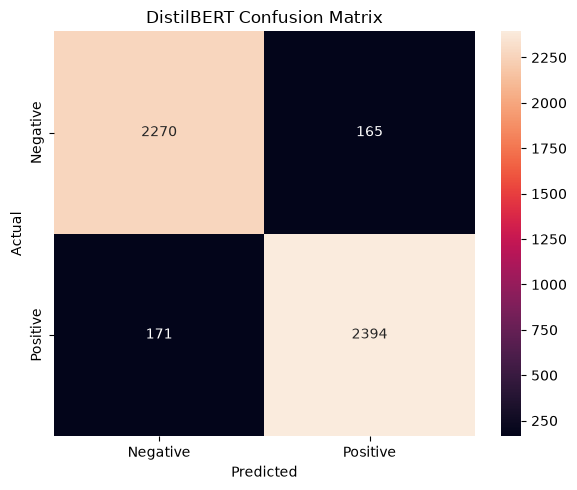

In [19]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT Confusion Matrix")

plt.tight_layout()
plt.show()

In [20]:
MODEL_DIR = Path("../models/distilbert")

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

trainer.save_model(
    str(MODEL_DIR)
)

tokenizer.save_pretrained(
    str(MODEL_DIR)
)

print("DistilBERT model saved successfully! ✅")
print("Saved to:", MODEL_DIR.resolve())

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT model saved successfully! ✅
Saved to: C:\Users\DELL\OneDrive\Desktop\ReviewSense\models\distilbert


In [21]:
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "DistilBERT"
    ],
    "Accuracy": [
        0.9112,
        final_accuracy
    ],
    "Precision": [
        0.9095,
        final_precision
    ],
    "Recall": [
        0.9180,
        final_recall
    ],
    "F1 Score": [
        0.9138,
        final_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF + Logistic Regression,0.9112,0.909500,0.918000,0.913800
1,DistilBERT,0.9328,0.935522,0.933333,0.934426


In [22]:
# ============================================================
# DISTILBERT ERROR ANALYSIS DATA
# ============================================================

predictions = trainer.predict(tokenized_test)

logits = predictions.predictions
y_true = predictions.label_ids

# Convert logits to probabilities
probabilities = torch.softmax(
    torch.tensor(logits),
    dim=-1
).numpy()

y_pred = np.argmax(probabilities, axis=1)

# Confidence of predicted class
confidence = probabilities[
    np.arange(len(y_pred)),
    y_pred
]

# Create error analysis dataframe
error_df = test_df.copy()

error_df["true_label"] = y_true
error_df["predicted_label"] = y_pred
error_df["confidence"] = confidence

# Human-readable labels
error_df["true_sentiment"] = error_df["true_label"].map({
    0: "Negative",
    1: "Positive"
})

error_df["predicted_sentiment"] = error_df["predicted_label"].map({
    0: "Negative",
    1: "Positive"
})

# Identify incorrect predictions
errors = error_df[
    error_df["true_label"] != error_df["predicted_label"]
].copy()

print("=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)

print("Total test samples:", len(error_df))
print("Correct predictions:", (error_df["true_label"] == error_df["predicted_label"]).sum())
print("Incorrect predictions:", len(errors))
print("Error rate:", len(errors) / len(error_df))

print("\nError distribution:")
print(
    errors.groupby(
        ["true_sentiment", "predicted_sentiment"]
    ).size()
)

c:\Users\DELL\OneDrive\Desktop\ReviewSense\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


ERROR ANALYSIS
Total test samples: 5000
Correct predictions: 4664
Incorrect predictions: 336
Error rate: 0.0672

Error distribution:
true_sentiment  predicted_sentiment
Negative        Positive               165
Positive        Negative               171
dtype: int64


In [23]:
# ============================================================
# INSPECT MISCLASSIFIED REVIEWS
# ============================================================

pd.set_option("display.max_colwidth", 200)

print("=" * 60)
print("SAMPLE MISCLASSIFIED REVIEWS")
print("=" * 60)

display(
    errors[
        [
            "text",
            "true_sentiment",
            "predicted_sentiment",
            "confidence"
        ]
    ]
    .sort_values("confidence")
    .head(20)
)

SAMPLE MISCLASSIFIED REVIEWS


,text,true_sentiment,predicted_sentiment,confidence
2139,"A necessary if unpleasant reading experience Rating this one is difficult. The rich symbolism of Tarot was forever impacted by the Order of the Golden Dawn, and A.E. Waite's ""Pictorial Key"" is a g...",Positive,Negative,0.502116
977,"blleeuurrgghhhh i have listened to this single and i want to feed it to the garbage can man. I urge you to avoid it at all costs, you will not notice the insipidly simple tune working it's way int...",Negative,Positive,0.507868
4305,"Very good but doesn't follow book We loved the movie very much...my 9 and 5 year old girls loved it, especially the ending. We didn't find it too scary at all.However, both my 9 year old and I enj...",Positive,Negative,0.507897
836,"Great card but difficult to setup As the other reviews noted, there are problems with installing this card, even though I got it working successfully in the end. Although it isn't my top pick for ...",Positive,Negative,0.510439
4738,"Not bad The technique of ""Image Streaming"" has shown promising results in certain cases. Much of the hype and propoganda, however, has been that the process can create a 20 point gain in IQ, relyi...",Positive,Negative,0.511108
4609,Hieroglyphic maps The Joy of OrigamiThis book is colorful and seemed promising for a beginner to self teach. The diagrams maybe okay if you already know what they are suppose to look like at each ...,Negative,Positive,0.511672
3184,No doubt about it! One look at all these reviews will leave you with no doubt that this is one of the best science fiction stories ever told. But wait! The best is yet to come. There are five othe...,Positive,Negative,0.524703
2516,Thumbs down God this was terrible.A group of children are marooned on a deserted island and must survive on their own. We see the rise and fall of their society as order is achieved; power corrupt...,Negative,Positive,0.526339
3950,"On the Origin of Species by Means of Natural Selection ... The true title that Darwin gave this thesis is: ""On the Origin of Species by Means of Natural Selection, or the Preservation of Favoured ...",Negative,Positive,0.546016
238,A Disappointing Misrepresentation Baking With Julia is an AMAZING Book.It is an exceptionally well written resource that is an accurate reflection of the PBS televised series of same name.When I s...,Negative,Positive,0.552032


In [24]:
print("=" * 60)
print("HIGH-CONFIDENCE MISCLASSIFICATIONS")
print("=" * 60)

display(
    errors[
        [
            "text",
            "true_sentiment",
            "predicted_sentiment",
            "confidence"
        ]
    ]
    .sort_values("confidence", ascending=False)
    .head(20)
)

HIGH-CONFIDENCE MISCLASSIFICATIONS


,text,true_sentiment,predicted_sentiment,confidence
923,You must read this book! This was my first encounter with the magical realism style and I love it! The Buendia family is quite possibly the most intriguing I have encountered in any book. A must r...,Negative,Positive,0.997700
4300,"A Great Book This is a GREAT book! I was thrilled to find it at my library, because everyone told me that I should read it. This unique story shows how the March sisters deal with problems togethe...",Negative,Positive,0.997563
1554,AWESOME!!! I fell in love with clay the first day he auditioned on AI. He is not only adorable he as a AWESOME voice!! girls are crazy over him!! and this CD is SOO GREAT!!IT'S BEAUTIFUL!! I LOVE ...,Negative,Positive,0.997317
552,Reaching for the Light I have really enjoyed this book! I have been learning a lot for my own healing. The reason I bought it was because a few months back I was able to read a portion of the book...,Negative,Positive,0.997175
4471,"ZOOM IN OR OUT Alvin Lee Zoom album is a non pretentious work, but a truly well done one. Simple, direct, great... From start to end is music at its best, to be joyful, to dance, no matter if the ...",Negative,Positive,0.997158
3414,thank you This one gift I could give my grown daughter. I read this book over and over to her as a child. It was in wonderful condition!,Negative,Positive,0.997068
2991,Great movie! I really liked this movie! They picked the perfect character for Pee Wee Herman to play. I thought the movie was really good except for the constant whinning of his mother! What about...,Negative,Positive,0.996988
4271,The Shelters of Stone My teenage daughter and I both enjoyed reading this series. This book in particular was full of interesting insight as to how people may have lived and communicated pre-ice a...,Negative,Positive,0.996942
4690,Retraction! Company fixed CD Works Great now! The company fixed the CD and sounds great now! Great company to work with. Very responsive. Would definitely buy from them again!Would definitely give...,Negative,Positive,0.996878
4674,"Cool Breeze This Honeywell product is excellent. It works quietly and easily circulates air while providing the desired breeze.I believe the unit will outlive its generous warranty, and would not ...",Negative,Positive,0.996798
